# Train With QLearning


In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [2]:
!pip install gymnasium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 958.1/958.1 kB 10.6 MB/s eta 0:00:00


In [3]:
!pip install gymnasium[other]

In [4]:
!pip install ale-py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 19.1 MB/s eta 0:00:00


## Classi di supporto

In [5]:

_color_conversion = {0: (0, 0, 0), 1: (74, 74, 74), 2: (111, 111, 111), 3: (142, 142, 142), 4: (170, 170, 170), 5: (192, 192, 192),
                     6: (214, 214, 214), 7: (236, 236, 236), 8: (72, 72, 0), 9: (105, 105, 15), 10: (134, 134, 29), 11: (162, 162, 42),
                     12: (187, 187, 53), 13: (210, 210, 64), 14: (232, 232, 74), 15: (252, 252, 84), 16: (124, 44, 0), 17: (144, 72, 17),
                     18: (162, 98, 33), 19: (180, 122, 48), 20: (195, 144, 61), 21: (210, 164, 74), 22: (223, 183, 85), 23: (236, 200, 96),
                     24: (144, 28, 0), 25: (163, 57, 21), 26: (181, 83, 40), 27: (198, 108, 58), 28: (213, 130, 74), 29: (227, 151, 89),
                     30: (240, 170, 103), 31: (252, 188, 116), 32: (148, 0, 0), 33: (167, 26, 26), 34: (184, 50, 50), 35: (200, 72, 72),
                     36: (214, 92, 92), 37: (228, 111, 111), 38: (240, 128, 128), 39: (252, 144, 144), 40: (132, 0, 100), 41: (151, 25, 122),
                     42: (168, 48, 143), 43: (184, 70, 162), 44: (198, 89, 179), 45: (212, 108, 195), 46: (224, 124, 210), 47: (236, 140, 224),
                     48: (80, 0, 132), 49: (104, 25, 154), 50: (125, 48, 173), 51: (146, 70, 192), 52: (164, 89, 208), 53: (181, 108, 224),
                     54: (197, 124, 238), 55: (212, 140, 252), 56: (20, 0, 144), 57: (51, 26, 163), 58: (78, 50, 181), 59: (104, 72, 198),
                     60: (127, 92, 213), 61: (149, 111, 227), 62: (169, 128, 240), 63: (188, 144, 252), 64: (0, 0, 148), 65: (24, 26, 167),
                     66: (45, 50, 184), 67: (66, 72, 200), 68: (84, 92, 214), 69: (101, 111, 228), 70: (117, 128, 240), 71: (132, 144, 252),
                     72: (0, 28, 136), 73: (24, 59, 157), 74: (45, 87, 176), 75: (66, 114, 194), 76: (84, 138, 210), 77: (101, 160, 225),
                     78: (117, 181, 239), 79: (132, 200, 252), 80: (0, 48, 100), 81: (24, 80, 128), 82: (45, 109, 152), 83: (66, 136, 176),
                     84: (84, 160, 197), 85: (101, 183, 217), 86: (117, 204, 235), 87: (132, 224, 252), 88: (0, 64, 48), 89: (24, 98, 78),
                     90: (45, 129, 105), 91: (66, 158, 130), 92: (84, 184, 153), 93: (101, 209, 174), 94: (117, 231, 194), 95: (132, 252, 212),
                     96: (0, 68, 0), 97: (26, 102, 26), 98: (50, 132, 50), 99: (72, 160, 72), 100: (92, 186, 92), 101: (111, 210, 111),
                     102: (128, 232, 128), 103: (144, 252, 144), 104: (20, 60, 0), 105: (53, 95, 24), 106: (82, 126, 45), 107: (110, 156, 66),
                     108: (135, 183, 84), 109: (158, 208, 101), 110: (180, 231, 117), 111: (200, 252, 132), 112: (48, 56, 0), 113: (80, 89, 22),
                     114: (109, 118, 43), 115: (136, 146, 62), 116: (160, 171, 79), 117: (183, 194, 95), 118: (204, 216, 110),
                     119: (224, 236, 124), 120: (72, 44, 0), 121: (105, 77, 20), 122: (134, 106, 38), 123: (162, 134, 56), 124: (187, 159, 71),
                     125: (210, 182, 86), 126: (232, 204, 99), 127: (252, 224, 112)}  # used in seaquest and qbert


In [6]:
# This file was extracted from the "OC_Atari" repository.
# Original URL: https://github.com/k4ntz/OC_Atari
# Source commit: abc1234
# Extraction date: January 15, 2025
# Original author: Quentin Delfosse (k4ntz)
# Original license: MIT

## Dependencies:
# - Requires Python 3.8 or higher.# - Libraries: Enum, Tuple

from enum import Enum
from typing import Tuple


class Orientation(Enum):  # 16-wind compass directions
    N = 0
    NNE = 1
    NE = 2
    ENE = 3
    E = 4
    ESE = 5
    SE = 6
    SSE = 7
    S = 8
    SSW = 9
    SW = 10
    WSW = 11
    W = 12
    WNW = 13
    NW = 14
    NNW = 15


class GameObject:
    """
    The Parent Class of every detected object in the Atari games (RAM Extraction mode)

    :ivar category: The Category of class name of the game object (e.g. Player, Ball).
    :vartype category: str

    :ivar x: The x positional coordinate on the image (on the horizontal axis).
    :vartype x: int

    :ivar y: The y positional coordinate on the image (on the vertical axis).
    :vartype y: int

    :ivar w: The width/horizontal size of the object (in pixels).
    :vartype w: int

    :ivar h: The height/vertical size of the object (in pixels).
    :vartype h: int

    :ivar prev_xy: The positional coordinates x and y of the previous time step in a tuple.
    :vartype prev_xy: (int, int)

    :ivar xy: Both positional coordinates x and y in a tuple.
    :vartype: (int, int)

    :ivar h_coords: History of coordinates, i.e. current (x, y) and previous (x, y) position.
    :vartype h_coords: [(int, int), (int, int)]

    :ivar dx: The pixel movement corresponding to: current_x - previous_x.
    :vartype dx: int

    :ivar dy: The pixel movement corresponding to: current_y - previous_y.
    :vartype dy: int

    :ivar xywh: The positional and width/height coordinates in a single tuple (x, y, w, h).
    :vartype xywh: (int, int, int, int)

    :ivar orientation: The orientation of the object (if available); game specific.
    :vartype orientation: int

    :ivar center: The center of the bounding box of the object.
    :vartype center: (int, int)

    :ivar hud: True, if part of the Heads Up Display, and thus not interactable.
    :vartype hud: bool
    """

    GET_COLOR = False
    GET_WH = False

    def __init__(self):
        self._rgb = (0, 0, 0)
        self._xy = (0, 0)
        self.wh = (0, 0)
        self._prev_xy = None
        self._orientation = None
        self.hud = False
        self._visible = True

    def __repr__(self):
        if self._visible:
            return f"{self.__class__.__name__} at ({self._xy[0]}, {self._xy[1]}), {self.wh}"
        return "\033[34m" + "NaO" + "\033[39m"  # blue color

    @property
    def category(self):
        return self.__class__.__name__

    @property
    def x(self):
        return self._xy[0]

    @property
    def y(self):
        return self._xy[1]

    @property
    def w(self):
        return self.wh[0]

    @w.setter
    def w(self, w):
        self.wh = int(w), self.h

    @property
    def h(self):
        return self.wh[1]

    @h.setter
    def h(self, h):
        self.wh = self.w, int(h)

    @property
    def prev_xy(self):
        if self._prev_xy is not None:
            return self._prev_xy
        else:
            return self._xy

    @prev_xy.setter
    def prev_xy(self, newval):
        self._prev_xy = newval

    @property
    def prev_x(self):
        return self.prev_xy[0]

    @property
    def prev_y(self):
        return self.prev_xy[1]

    @property
    def xy(self):
        return self._xy

    @xy.setter
    def xy(self, xy):
        self._xy = (int(xy[0]), int(xy[1]))

    @x.setter
    def x(self, x):
        self._xy = int(x), self.y

    @y.setter
    def y(self, y):
        self._xy = self.x, int(y)

    # returns 2 lists with current and past coords
    @property
    def h_coords(self):
        return [self._xy, self.prev_xy]

    @property
    def dx(self):
        return self._xy[0] - self.prev_xy[0]

    @property
    def dy(self):
        return self._xy[1] - self.prev_xy[1]

    @property
    def xywh(self):
        return self._xy[0], self._xy[1], self.wh[0], self.wh[1]

    @xywh.setter
    def xywh(self, xywh):
        self._xy = xywh[0], xywh[1]
        self.wh = xywh[2], xywh[3]

    def _save_prev(self):
        self._prev_xy = self._xy

    @property
    def visible(self):
        return self._visible

    @visible.setter
    def visible(self, v):
        self._visible = v

    @property
    def _nsrepr(self):
        if not self._visible:
            return [0, 0]
        return [self.x, self.y]

    @property
    def _ns_meaning(self):
        """NeuroSymbolic Meaning"""
        return ["POSITION"]

    @property
    def _nslen(self):
        return len(self._nsrepr)

    @property
    def _ns_types(self):
        return [Tuple[int, int]]

    @property
    def rgb(self):
        if self.visible:
            return self._rgb
        return 0, 0, 0

    @rgb.setter
    def rgb(self, rgb):
        self._rgb = rgb

    @property
    def orientation(self):
        return self._orientation

    @orientation.setter
    def orientation(self, o):
        self._orientation = o

    @property
    def center(self):
        return self._xy[0] + self.wh[0]/2, self._xy[1] + self.wh[1]/2

    def is_on_top(self, other):
        """
        Returns ``True`` if this and another gameobject overlap.

        :return: True if objects overlap
        :rtype: bool
        """
        return (other.x <= self.x <= other.x + other.w) and \
            (other.y <= self.y <= other.y + other.h)

    def manathan_distance(self, other):
        """
        Returns the manathan distance between the center of both objects.

        :return: True if objects overlap
        :rtype: bool
        """
        c0, c1 = self.center, other.center
        return abs(c0[0] - c1[0]) + abs(c0[1] - c1[1])

    def closest_object(self, others):
        """
        Returns the closest object from others, based on manathan distance between the center of both objects.

        :return: (Index, Object) from others
        :rtype: int
        """
        if len(others) == 0:
            return None
        return min(enumerate(others), key=lambda item: self.manathan_distance(item[1]))

    def _is_equivalent(self, other):
        if self.category != other.category:
            return False
        iou_value = self.iou(other)
        return iou_value > 0.8

    def iou(self, other):
        # Calculate the (x, y) coordinates of the intersection rectangle
        if self.category == "NoObject" and other.category == "NoObject":
            return 1
        x1 = max(self.x, other.x)
        y1 = max(self.y, other.y)
        x2 = min(self.x + self.w, other.x + other.w)
        y2 = min(self.y + self.h, other.y + other.h)

        # Calculate the area of intersection rectangle
        inter_width = max(0, x2 - x1)
        inter_height = max(0, y2 - y1)
        inter_area = inter_width * inter_height

        # Calculate the area of both bounding boxes
        area_self = self.w * self.h
        area_other = other.w * other.h

        # Calculate the union area
        union_area = area_self + area_other - inter_area

        # Calculate IoU
        if union_area == 0:
            return 0  # Prevent division by zero
        return inter_area / union_area

    @property
    def properties(self):
        """
        All the properties of the object in a list.

        :return: The properties of the object.
        :rtype: list
        """
        ignore = ["properties", "GET_COLOR", "GET_WH",
                  "xy", "wh", "prev_xy", "h_coords", "xywh"]
        properties = [prop for prop in self.__dir__()]
        [properties.remove(p) for p in ignore if p in properties]
        return [prop for prop in properties
                if not prop.startswith("_") and
                not callable(self.__getattribute__(prop))]

    def __bool__(self):
        return self._visible


class NoObject(GameObject):
    """
    This class represents a non-existent object. It is used to fill in the gaps when no object is detected.
    """

    def __init__(self, nslen=2):
        super().__init__()
        self.nslen = nslen
        self.rgb = (0, 0, 0)

    def _save_prev(self):
        pass

    def __bool__(self):
        return False

    def __eq__(self, other):
        return isinstance(other, NoObject)

    @property
    def _nsrepr(self):
        return [0 for _ in range(self.nslen)]

    @property
    def _ns_meaning(self):
        return ["POSITION"]

    @property
    def _ns_types(self):
        return [Tuple[int, int]]

    def __repr__(self):
        # return "NaO"
        # return "\033[31m" + "NaO" + "\033[39m" # red color
        return "\033[34m" + "NaO" + "\033[39m"  # blue color


class ValueObject(GameObject):
    """
    This class represents a game object that incorporates any notion of a value.
    For example:
    * the score of the player (or sometimes Enemy).
    * the level of useable/deployable resources (oxygen bars, ammunition bars, power gauges, etc.)
    * the clock/timer

    :ivar value: The value of the score.
    :vartype value: int
    """

    def __init__(self):
        super().__init__()
        self._value = 0
        self._prev_value = None

    @property
    def value(self):
        return self._value

    @value.setter
    def value(self, value):
        self._value = None if value is None else int(value)

    @property
    def prev_value(self):
        if self._prev_value is not None:
            return self._prev_value
        else:
            return self._value

    def _save_prev(self):
        super()._save_prev()
        self._prev_value = self._value

    @property
    def value_diff(self):
        return self.value - self.prev_value


In [7]:
import numpy as np
import sys

"""
RAM extraction for the game Q*BERT. Supported modes: ram.

"""

MAX_NB_OBJECTS = {'Player': 1, 'Cube': 21, 'Disk': 2,
                  'PurpleBall': 1, 'RedBall': 1, 'GreenBall': 1, 'Coily': 1, 'Sam': 1}
MAX_NB_OBJECTS_HUD = {'Player': 1, 'Cube': 21, 'Disk': 2, 'PurpleBall': 1,
                      'RedBall': 1, 'GreenBall': 1, 'Coily': 1, 'Sam': 1, 'Score': 1, 'Lives': 1}


_cubes_cinfo = [21,               # row of 1
                52,  54,            # row of 2
                83, 85,  87,           # row of 3
                98, 100, 102, 104,       # row of 4
                1,  3,   5,   7,  9,      # row of 5
                32, 34, 36,  38,  40, 42]   # row of 6


_cubes_pos = [(68, 34), (56, 62), (84, 62), (44, 91), (68, 91), (96, 91), (32, 120), (56, 120), (84, 120), (108, 120), (20, 149),
              (44, 149), (68, 149), (96, 149), (120, 149), (8, 178), (32, 178), (56, 178), (84, 178), (108, 178), (132, 178)]

_diskposes = [(12, 138), (140, 138)]


class Player(GameObject):
    """
    The player figure: Q*bert.
    """

    def __init__(self):
        super(Player, self).__init__()
        self._xy = 78, 103
        self.wh = 8, 20
        self.rgb = 181, 83, 40
        self.hud = False


class Cube(GameObject):
    """
    The cubes.
    """

    def __init__(self):
        super().__init__()
        self._xy = (0, 0)
        self.rgb = 45, 87, 176
        self.wh = (20, 5)
        self.hud = False


class Disk(GameObject):
    """
    The lift disks at the sides.
    """

    def __init__(self):
        super().__init__()
        self._xy = (0, 0)
        self.rgb = 24, 59, 157
        self.wh = (8, 2)
        self.hud = False


class PurpleBall(GameObject):
    """
    The purple ball, which hatches Coily when reaching the bottom of the pyramid.
    """

    def __init__(self):
        super(PurpleBall, self).__init__()
        self._xy = 78, 103
        self.wh = 7, 9
        self.rgb = 146, 70, 192
        self.hud = False


class RedBall(GameObject):
    """
    The red ball.
    """

    def __init__(self):
        super(RedBall, self).__init__()
        self._xy = 78, 103
        self.wh = 7, 9
        self.rgb = 223, 183, 85
        self.hud = False


class GreenBall(GameObject):
    """
    The green ball.
    """

    def __init__(self):
        super(GreenBall, self).__init__()
        self._xy = 78, 103
        self.wh = 7, 9
        self.rgb = 50, 132, 50
        self.hud = False


class Coily(GameObject):
    """
    A class representing Coily, one of Q*bert's enemies, who hatches from the purple ball.
    """

    def __init__(self):
        super(Coily, self).__init__()
        self._xy = 78, 103
        self.wh = 8, 21
        self.rgb = 146, 70, 192
        self.hud = False


class Sam(GameObject):
    """
    A class representing Sam, one of Q*bert's enemies, who changes the cubes' color back to original.
    """

    def __init__(self):
        super(Sam, self).__init__()
        self._xy = 78, 103
        self.wh = 8, 18
        self.rgb = 50, 132, 50
        self.hud = False


class Score(GameObject):
    """
    The player score display.
    """

    def __init__(self):
        super(Score, self).__init__()
        self._xy = 34, 6
        self.wh = 37, 7
        self.rgb = 210, 210, 64
        self.hud = True


class Lives(GameObject):
    """
    The indicator for the remaining lives.
    """

    def __init__(self):
        super(Lives, self).__init__()
        self._xy = 33, 16
        self.wh = 24, 12
        self.rgb = 210, 210, 64
        self.hud = True


# parses MAX_NB* dicts, returns default init list of objects
def _get_max_objects(hud=False):

    def fromdict(max_obj_dict):
        objects = []
        mod = sys.modules[__name__]
        for k, v in max_obj_dict.items():
            for _ in range(0, v):
                objects.append(getattr(mod, k)())
        return objects

    if hud:
        return fromdict(MAX_NB_OBJECTS_HUD)
    return fromdict(MAX_NB_OBJECTS)


def _init_objects_ram(hud=True):
    """
    (Re)Initialize the objects
    """
    objects = [Player()]
    for pos in _cubes_pos:
        cub = Cube()
        cub.xy = pos
        objects.append(cub)
    for dpos in _diskposes:
        dis = Disk()
        dis.xy = dpos
        objects.append(dis)

    global coil_prev_x
    global coil_prev_y
    coil_prev_x = 0
    coil_prev_y = 0

    global last_i
    last_i = -1
    global purple_i
    purple_i = -1
    global green_i
    green_i = -1
    global last_74
    last_74 = 0
    global last_lives
    last_lives = 2
    global last_105
    last_105 = 0
    global last_103
    last_103 = 0

    objects.extend([None] * 4)  # Coily, pruple_ball, green_ball, sam
    if hud:
        objects.extend([None] * 2)
    return objects


def _detect_objects_ram(objects, ram_state, hud=True):
    player = objects[0]
    cubes = objects[1:22]
    for cube, ccinf in zip(cubes, _cubes_cinfo):
        cube.rgb = _color_conversion[ram_state[ccinf]//2]
    if 16 < ram_state[67] < 210:
        if player is None:
            player = Player()
            objects[0] = player
        if ram_state[59] == 255:  # falling
            player.xy = player.xy[0], ram_state[33] - 52
        elif ram_state[67] < 70:
            player.xy = ram_state[43] - 3, ram_state[67] - 8
        elif ram_state[67] < 100:
            player.xy = ram_state[43] - 3, ram_state[67] - 7
        else:
            player.xy = ram_state[43] - 3, ram_state[67] - 6
    else:
        objects[0] = None
    for diskpos, rs, position in zip([22, 23], [112, 122], _diskposes):  # disks
        if ram_state[rs] == 0:
            if objects[diskpos] is not None:
                objects[diskpos] = None
        else:
            if objects[diskpos] is None:
                disk = Disk()
                objects[diskpos] = disk
                disk.xy = position
            objects[diskpos].rgb = _color_conversion[ram_state[rs]//2]

    global coil_prev_x, coil_prev_y
    coily = objects[24]
    if ram_state[39] != 255:
        if coily is None:
            coily = Coily()
            objects[24] = coily
        # The x value switches too early in the RAM, therfore we use the
        # y value changes as a trigger for the Position switch
        if coil_prev_y != ram_state[39]:
            if ram_state[56] > 8:
                coily.xy = _calc_enemy_x(
                    ram_state[71]), (ram_state[39] * 30) + 6
                coily.wh = 8, 21
            elif ram_state[56] > 6:
                coily.xy = _calc_enemy_x(
                    ram_state[71]), (ram_state[39] * 30) + 9
                coily.wh = 8, 18
            elif ram_state[56] > 3:
                coily.xy = _calc_enemy_x(
                    ram_state[71]), (ram_state[39] * 30) + 11
                coily.wh = 8, 16
            elif ram_state[56] == 1:
                coily.xy = _calc_enemy_x(
                    ram_state[71]), (ram_state[39] * 30) + 6
                coily.wh = 8, 21
            else:
                coily.xy = _calc_enemy_x(
                    ram_state[71]), (ram_state[39] * 30) + 9
                coily.wh = 8, 18
        else:  # Else the position remains the same as before
            if ram_state[56] > 8:
                coily.xy = coil_prev_x, (ram_state[39] * 30) + 6
                coily.wh = 8, 21
            elif ram_state[56] > 6:
                coily.xy = coil_prev_x, (ram_state[39] * 30) + 9
                coily.wh = 8, 18
            elif ram_state[56] > 3:
                coily.xy = coil_prev_x, (ram_state[39] * 30) + 11
                coily.wh = 8, 16
            elif ram_state[56] == 1:
                coily.xy = coil_prev_x, (ram_state[39] * 30) + 6
                coily.wh = 8, 21
            else:
                coily.xy = coil_prev_x, (ram_state[39] * 30) + 9
                coily.wh = 8, 18
        x, _ = coily.xy
        coil_prev_x = x
        coil_prev_y = ram_state[39]
    else:
        objects[24] = None
        coil_prev_x = 0
        coil_prev_y = 0

    # The object y values are not part of the RAM, instead the game
    # interprets the RAM position 75 as the highest  y position an object can be at and 79 as the lowest.
    # The x value of the object are the respective RAM values at these Positions.
    # E.g: RAM 79 has value 0: The object is on the bottem left corner of the pyramid.
    #      RAM 75 has value 6: The object is one to the right of the tip of the pyramid (second row right platform)
    # With each step an object takes they will go down one row and the next RAM position in line determins their x
    # and y position.
    # The big problem with this is that the RAM values stay the same even if there is no object on the specified
    # platform anymore.
    # (You might be able to find a RAM value carrying information when the next step is taken by an object)

    global last_i
    global purple_i
    global green_i
    global last_74
    global last_105
    global last_103
    global last_lives

    purple_ball, green_ball, sam = objects[25], objects[26], objects[27]

    # if ram_state[59] == 255:
    if last_lives != ram_state[8]:
        green_i = -1
        purple_i = -1
        last_i = -1
        last_lives = ram_state[8]
        last_74 = ram_state[74]
        objects[25], objects[26], objects[27] = None, None, None
    elif ram_state[74]:
        if last_74 != ram_state[74]:
            last_74 = ram_state[74]
            if last_i >= 0:
                last_i = last_i + 1
            if purple_i >= 0:
                purple_i = purple_i + 1
            if green_i >= 0:
                green_i = green_i + 1

        if last_103 != ram_state[103]:
            if ram_state[103] == 17:
                green_i = 0
            last_103 = ram_state[103]
        elif green_i > 4:
            green_i = -1
        if green_i >= 0 and green_i < 5:
            if green_ball is None:
                green_ball = GreenBall()
                objects[26] = green_ball
            if player is not None:
                b_x, b_y = _calc_enemy_x(
                    ram_state[75 + green_i]), ((green_i + 1) * 30) + 7 - green_i
                p_x, p_y = player.xy
                if (b_x - p_x) < 9 and (b_x - p_x) > -9 and (b_y - p_y) < 9 and (b_y - p_y) > -9:
                    objects[27] = None
                    green_i = -1
            if ram_state[56] < 7:
                green_ball.xy = _calc_enemy_x(
                    ram_state[75 + green_i]) + 1, ((green_i + 1) * 30) + 23 - green_i
                green_ball.wh = 7, 6
            else:
                green_ball.xy = _calc_enemy_x(
                    ram_state[75 + green_i]) + 1, ((green_i + 1) * 30) + 9 - green_i
                green_ball.wh = 7, 9
        else:
            objects[26] = None

        if ram_state[119] != 0:
            objects[25] = None
            purple_i = -1
        elif ram_state[119] == 0 and purple_i < 0 and objects[24] is None:
            purple_i = 0
        elif purple_i > 4:
            purple_i = -1
        if purple_i >= 0 and purple_i < 5:
            if green_i != purple_i:
                if purple_ball is None:
                    purple_ball = PurpleBall()
                    objects[25] = purple_ball
                if ram_state[56] < 7:
                    purple_ball.xy = _calc_enemy_x(
                        ram_state[75 + purple_i]) + 1, ((purple_i + 1) * 30) + 23 - purple_i
                    purple_ball.wh = 7, 6
                else:
                    purple_ball.xy = _calc_enemy_x(
                        ram_state[75 + purple_i]) + 1, ((purple_i + 1) * 30) + 9 - purple_i
                    purple_ball.wh = 7, 9
            else:
                purple_i = -1
        else:
            objects[25] = None

        if last_105 != ram_state[105]:
            if ram_state[105] == 6:
                last_i = 0
            last_105 = ram_state[105]
        if last_i >= 0 and last_i < 5:
            if sam is None:
                sam = Sam()
                objects[27] = sam
            if player is not None:
                s_x, s_y = _calc_enemy_x(
                    ram_state[75 + last_i]), ((last_i + 1) * 30) + 12 - last_i
                p_x, p_y = player.xy
                if (s_x - p_x) < 7 and (s_x - p_x) > -7 and (s_y - p_y) < 7 and (s_y - p_y) > -7:
                    objects[27] = None
                    last_i = -1
            sam.xy = _calc_enemy_x(
                ram_state[75 + last_i]), ((last_i + 1) * 30) + 12 - last_i
        else:
            objects[27] = None
        if last_i > 4:
            last_i = -1

    if hud:
        score, lives = objects[28], objects[29]
        score = Score()
        objects[28] = score
        if ram_state[8] == 2:
            lives = Lives()
        elif ram_state[8] == 1:
            lives = Lives()
            lives.wh = 16, 12
        elif ram_state[8] == 0:
            lives = Lives()
            lives.wh = 8, 12
        else:
            lives = None
        objects[29] = lives

    return objects


def _detect_objects_qbert_raw(info, ram_state):
    player = ram_state[43], ram_state[67]
    enemy = ram_state[47], ram_state[46]

    # 69 105
    # ram[56] timer
    # ram_state[126] maybe sprite 171 = jump and 201 normal
    # ram[41]: 0 ball, 7 coily
    # ram[75:80]: enemy spawn

    info["ram-slice"] = player + enemy


def _calc_enemy_x(value):
    """
    Calculates the enemy x position from the RAM value
    """
    res = 0
    for i in range(value + 1):
        if i <= 1:
            res = res + 13
        elif i == 6:
            res = res + 16
        else:
            res = res + 12
    return res


In [8]:
from collections import defaultdict
import gymnasium as gym
import numpy as np


class QBAgent:
    def __init__(
        self,
        env: gym.Env,
        learning_rate: float,
        initial_epsilon: float,
        epsilon_decay: float,
        final_epsilon: float,
        discount_factor: float = 0.95,
        q_values = None
    ):
        """Initialize a Reinforcement Learning agent with an empty dictionary
        of state-action values (q_values), a learning rate and an epsilon.

        Args:
            env: The training environment
            learning_rate: The learning rate
            initial_epsilon: The initial epsilon value
            epsilon_decay: The decay for epsilon
            final_epsilon: The final epsilon value
            discount_factor: The discount factor for computing the Q-value
        """
        self.env = env

        if q_values == None:
            self.q_values = defaultdict(lambda: np.zeros(env.action_space.n))
        else:
            self.q_values = defaultdict(lambda: np.zeros(env.action_space.n), q_values)

        self.lr = learning_rate
        self.discount_factor = discount_factor

        self.epsilon = initial_epsilon
        self.epsilon_decay = epsilon_decay
        self.final_epsilon = final_epsilon

        self.training_error = []

    def get_action(self, obs: tuple[int, int, bool]) -> int:
        """
        Returns the best action with probability (1 - epsilon)
        otherwise a random action with probability epsilon to ensure exploration.
        """
        # with probability epsilon return a random action to explore the environment
        if np.random.random() < self.epsilon:
            return self.env.action_space.sample()
        # with probability (1 - epsilon) act greedily (exploit)
        else:
            return int(np.argmax(self.q_values[obs]))

    def update(
        self,
        obs: tuple[int, int, bool],
        action: int,
        reward: float,
        terminated: bool,
        next_obs: tuple[int, int, bool],
    ):

        """Updates the Q-value of an action."""
        future_q_value = (not terminated) * np.max(self.q_values[next_obs])
        temporal_difference = (
            reward + self.discount_factor * future_q_value - self.q_values[obs][action]
        )

        self.q_values[obs][action] = (
            self.q_values[obs][action] + self.lr * temporal_difference
        )
        self.training_error.append(temporal_difference)

    def decay_epsilon(self):
        self.epsilon = max(self.final_epsilon, self.epsilon - self.epsilon_decay)

    def get_Qvalues(self):
        dictionary =  dict(self.q_values)
        return dictionary

In [14]:
import gymnasium as gym
import ale_py
from tqdm import tqdm
import pickle
from gymnasium.wrappers import RecordEpisodeStatistics, RecordVideo

gym.register_envs(ale_py)
# hyperparameters
learning_rate = 0.01
n_episodes = 100
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

env = gym.make("ALE/Qbert-ram-v5")
env = gym.wrappers.RecordEpisodeStatistics(env, buffer_length=n_episodes)

agent = QBAgent(
    env=env,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

# history = []

for episode in tqdm(range(n_episodes)):
    obs_wrapper = _init_objects_ram()
    obs, info = env.reset()
    obs_wrapper = tuple( _detect_objects_ram(obs_wrapper, obs))
    done = False
    # history.append(obs)
    # print(obs)


    # play one episode
    while not done:
        action = agent.get_action(obs_wrapper)
        next_obs, reward, terminated, truncated, info = env.step(action)
        # history.append(next_obs)

        # print(next_obs)
        # print(str(obs) + "- Lenght: " + str(len(obs)))
        # print(str(next_obs) +  "- Lenght: " + str(len(obs)))

        obs_wrapper = _init_objects_ram()
        obs_wrapper =  tuple(_detect_objects_ram(obs_wrapper, obs))
        next_obs_wrapper = _init_objects_ram()
        next_obs_wrapper = tuple(_detect_objects_ram(next_obs_wrapper, next_obs))
        # update the agent
        agent.update(obs_wrapper, action, reward, terminated, next_obs_wrapper)

        # update if the environment is done and the current obs
        done = terminated or truncated
        obs = next_obs

    agent.decay_epsilon()



100%|██████████| 100/100 [00:48<00:00,  2.06it/s]


In [15]:
print(f"Return Queue: {env.return_queue}")


Return Queue: deque([50.0, 50.0, 375.0, 175.0, 125.0, 25.0, 100.0, 125.0, 50.0, 125.0, 75.0, 75.0, 75.0, 125.0, 125.0, 25.0, 50.0, 175.0, 150.0, 25.0, 50.0, 125.0, 75.0, 75.0, 50.0, 75.0, 0.0, 225.0, 75.0, 400.0, 0.0, 50.0, 500.0, 200.0, 50.0, 50.0, 50.0, 575.0, 200.0, 25.0, 575.0, 25.0, 100.0, 50.0, 125.0, 200.0, 50.0, 75.0, 175.0, 475.0, 450.0, 150.0, 25.0, 175.0, 500.0, 425.0, 500.0, 325.0, 100.0, 150.0, 25.0, 25.0, 150.0, 50.0, 550.0, 100.0, 525.0, 125.0, 275.0, 375.0, 125.0, 25.0, 75.0, 275.0, 275.0, 100.0, 175.0, 100.0, 100.0, 50.0, 100.0, 150.0, 25.0, 125.0, 425.0, 50.0, 0.0, 125.0, 75.0, 525.0, 150.0, 125.0, 50.0, 0.0, 150.0, 425.0, 575.0, 75.0, 75.0, 400.0], maxlen=100)


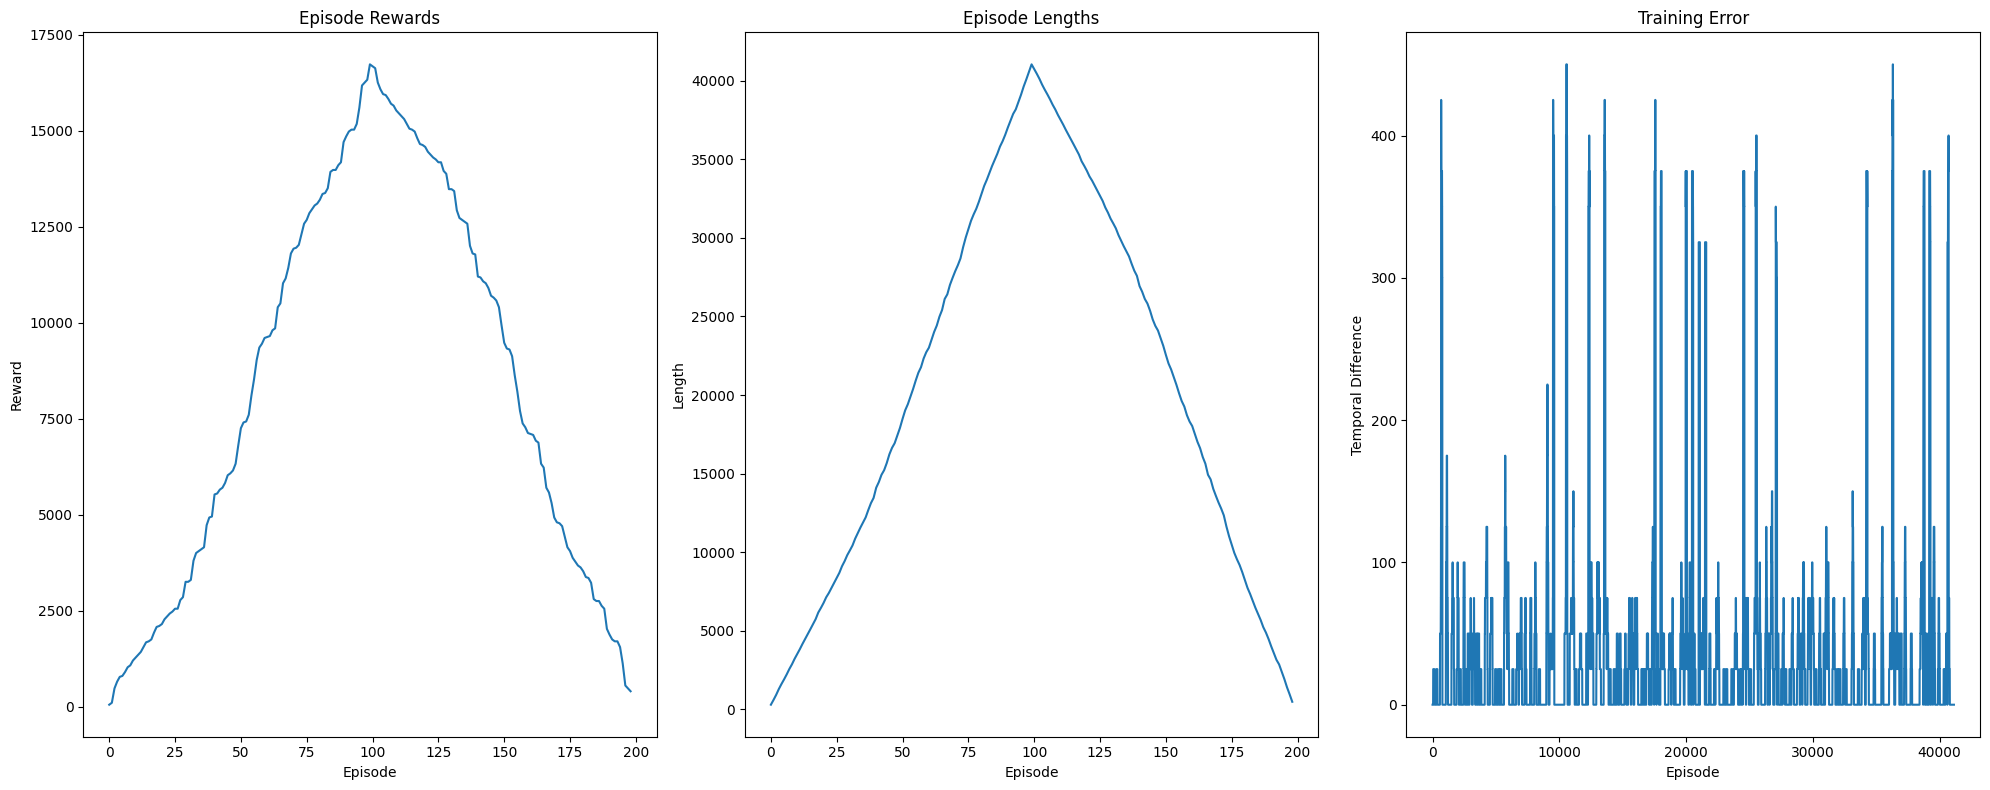

In [16]:
from matplotlib import pyplot as plt
# visualize the episode rewards, episode length and training error in one figure
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

# np.convolve will compute the rolling mean for 100 episodes

axs[0].plot(np.convolve(env.return_queue, np.ones(100)))
axs[0].set_title("Episode Rewards")
axs[0].set_xlabel("Episode")
axs[0].set_ylabel("Reward")

axs[1].plot(np.convolve(env.length_queue, np.ones(100)))
axs[1].set_title("Episode Lengths")
axs[1].set_xlabel("Episode")
axs[1].set_ylabel("Length")

axs[2].plot(np.convolve(agent.training_error, np.ones(100)))
axs[2].set_title("Training Error")
axs[2].set_xlabel("Episode")
axs[2].set_ylabel("Temporal Difference")

plt.tight_layout()
plt.show()

In [10]:
env = gym.make("ALE/Qbert-ram-v5", render_mode="rgb_array")  # replace with your environment
env = RecordVideo(env, video_folder="videos_first", name_prefix="eval",
                  episode_trigger=lambda x: True)
env = RecordEpisodeStatistics(env, buffer_length=1)

In [ ]:
for episode_num in range(4):
    obs_wrapper = _init_objects_ram()
    obs, info = env.reset()
    obs_wrapper = tuple( _detect_objects_ram(obs_wrapper, obs))
    done = False

    while not done:
        action = agent.get_action(obs_wrapper)
        obs, reward, terminated, truncated, info = env.step(action)
        #print(reward)
        obs_wrapper = _init_objects_ram()
        obs_wrapper = tuple( _detect_objects_ram(obs_wrapper, obs))

        done = terminated or truncated
env.close()

0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
